------------------------------------------------
Section 1: Environment Setup
------------------------------------------------

In [1]:
# Install packages if needed (uncomment if running locally)
!pip install transformers gensim scikit-learn numpy pandas


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [85]:
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
import gensim.downloader as api
import numpy as np
import pandas as pd
import os
from sklearn.metrics.pairwise import cosine_similarity

from IPython.display import display, Markdown

from warnings import filterwarnings
filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


In [3]:
print("Libraries imported successfully.")

Libraries imported successfully.


------------------------------------------------
Section 2: Load Text Generation Model
------------------------------------------------

In [5]:
generator = pipeline("text-generation", model="distilgpt2")

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 520.68it/s, Materializing param=transformer.wte.weight]            


------------------------------------------------
Section 3: Text Generation Example
------------------------------------------------

In [6]:
prompt = "AI is transforming industries by"

In [7]:
outputs = generator(
    prompt,
    max_length=50,
    num_return_sequences=3,
    do_sample=True,
    temperature=0.9,
    top_p=0.95
)

Passing `generation_config` together with generation-related arguments=({'top_p', 'temperature', 'do_sample', 'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [9]:
print(f"Text Generation Outputs for {prompt}")
for i, output in enumerate(outputs):
    print(f"\nOutput {i+1}:")
    print(output['generated_text'])
    print("-"*50)

Text Generation Outputs for AI is transforming industries by

Output 1:
AI is transforming industries by transforming them from one that is a threat to the rest of us.


"We don't need to change our economy to change it to change everything," he says. "It's important to be able to change what we're doing."
--------------------------------------------------

Output 2:
AI is transforming industries by giving workers an opportunity to lead the way.




The number of jobs generated by these new technologies, especially those in factories that employ young people and low-skilled workers, is more than double that of previous years. The number of young people in the workforce rose by 25.5% in 2011, compared to the same time as it was in 2013, according to a report by the World Bank.
"This is the highest rate of growth in the history of the economy, according to the World Bank, and the fastest-growing proportion of jobs in the developed world," said Dr C. B. K. Chappell, head of the World Bank

------------------------------------------------
Section 4: Tokenization Example
------------------------------------------------

In [10]:
tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
sentence = "LLMs are powerful tools for natural language understanding."
encoding = tokenizer(sentence)

In [11]:
token_ids = encoding["input_ids"]
tokens = tokenizer.convert_ids_to_tokens(token_ids)
seq_length = len(token_ids)

In [12]:
print("\nTokenization Example")
print("Sentence:", sentence)
print("\nTokens:", tokens)
print("\nToken IDs:", token_ids)
print("\nSequence Length:", seq_length)


Tokenization Example
Sentence: LLMs are powerful tools for natural language understanding.

Tokens: ['LL', 'Ms', 'Ġare', 'Ġpowerful', 'Ġtools', 'Ġfor', 'Ġnatural', 'Ġlanguage', 'Ġunderstanding', '.']

Token IDs: [3069, 10128, 389, 3665, 4899, 329, 3288, 3303, 4547, 13]

Sequence Length: 10


------------------------------------------------
Section 5: Prompt Engineering Examples
------------------------------------------------

### SUMMARISATION: USING GPT MODEL

In [20]:
# Summarization Prompt
prompt_summary = '''
Summarize the following text in 30 words or less:

Text:
True ambition is not merely the pursuit of accolades, 
but a methodical dedication to refining one's craft. 
Many individuals falter because they equate success with instantaneous recognition, 
overlooking the incremental progress necessary for mastery. 
A truly ambitious person welcomes failure as a formative experience, 
extracting lessons from every setback rather than succumbing to despair. 
This tenacious mindset requires a delicate balance of confidence and humility, 
allowing for continuous adaptation in a rapidly changing environment. 
Furthermore, prioritizing long-term goals over immediate gratification distinguishes 
the visionary from the dreamer. 
Ultimately, consistent effort, when paired with strategic thinking, yields lasting 
achievement, transforming raw talent into exceptional skill.

Summary:
'''

In [22]:
summary_output = generator(prompt_summary, 
                           max_new_tokens = 60, 
                           do_sample=True,
                           temperature=0.7,
                           top_p=0.9, 
                           repetition_penalty=1.2
                           )
print("\nSummarization Output:")
processed_text = summary_output[0]["generated_text"]
summary = processed_text.replace(prompt_summary, "").strip()

print(summary)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Summarization Output:
To summarize, In my book “The Dreamers” I propose that many successful people will have great opportunity at some point during their lifetime if given more time—and an even greater chance at achieving such outcomes without ever becoming convinced by all other factors (such being your own). If


### SUMMARISATION USING SUMMARISTION MODEL (DistilBART)

In [24]:
def summarise_with_model(paragraph, model_name):
    """
    Summarise the input paragraph using the specified pre-trained model.
    - model_name: the name of the pre-trained model to use for summarization (e.g., 't5-small', 'facebook/bart-large-cnn')
    - the function can be modified to accept additional parameters for generation (e.g., max_length, num_beams) to allow for more control over the summarization process    
    - tokenizer initiated for model_name to allow for flexibility in which model to use for summarization
    """
    ## Load the model and tokenizer, and prepare the input
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    ## Tokenise the input paragraph
    inputs = tokenizer(paragraph, return_tensors='pt', truncation=True, max_length=1024)

    ## Generate the summary
    summary_ids = model.generate(inputs['input_ids'], 
                                max_length=60, 
                                min_length=20, 
                                length_penalty=2.0, 
                                num_beams=4, 
                                early_stopping=True
                                )
    ## Decode the summary
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    return summary

In [ ]:
models = ['sshleifer/distilbart-cnn-12-6', 'facebook/bart-large-cnn']

## loop through models, generate summaries, and store results in a DataFrame for display
rows = []

## Append result from GPT2 generator for summary
rows.append({
    "model":"text generation distilgpt2",
    "summary":summary
})

## For each model, generate summary results
for model_name in models:
    summary = summarise_with_model(prompt_summary, model_name)
    rows.append({
        "model": model_name,
        "summary": summary
    })
df = pd.DataFrame(rows)
display(df)

Please make sure the generation config includes `forced_bos_token_id=0`. 
Loading weights: 100%|██████████| 358/358 [00:00<00:00, 1121.23it/s, Materializing param=model.shared.weight]                                 
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Loading weights: 100%|██████████| 511/511 [00:00<00:00, 1236.48it/s, Materializing param=model.encoder.layers.11.self_attn_layer_norm.weight]   


,model,summary
0,text generation distilgpt2,"To summarize, In my book “The Dreamers” I prop..."
1,sshleifer/distilbart-cnn-12-6,A truly ambitious person welcomes failure as ...
2,facebook/bart-large-cnn,A truly ambitious person welcomes failure as a...


In [30]:
for _, row in df.iterrows():
    print(f'Model name: {row['model']}')
    print(row['summary'])
    print('-'*50)

Model name: text generation distilgpt2
To summarize, In my book “The Dreamers” I propose that many successful people will have great opportunity at some point during their lifetime if given more time—and an even greater chance at achieving such outcomes without ever becoming convinced by all other factors (such being your own). If
--------------------------------------------------
Model name: sshleifer/distilbart-cnn-12-6
 A truly ambitious person welcomes failure as a formative experience . prioritizing long-term goals over immediate gratification distinguishes the visionary from the dreamer . Ultimately, consistent effort, when paired with strategic thinking, yields lasting achievement .
--------------------------------------------------
Model name: facebook/bart-large-cnn
A truly ambitious person welcomes failure as a formative experience, extracting lessons from every setback rather than succumbing to despair. prioritizing long-term goals over immediate gratification distinguishes 

#### COMMENTARY ON DIFFERENT WAYS OF SUMMARISATION
- GPT2 prompt (DistilGPT2) can be used to demo ability to summarise 
    - This is a general purpose model that predicts the next token in sequence 
    - The objective of the model is next work prediction and langauge generation, not compression of text
    - The result **can** resemble summary, but often the result is hallucination (as seen above)
- Using model specifically trained to summarise like distilbart / large bart improves the results
    - These models are based on encode - decoder architecture 
    - The models are fine tuned on data sets with document/summary pair (labelled data)
    - This training / fine tuning improves the quality of summarisation
- Task specific models should be adopted for best results


| Model       | Behaviour              |
|-------------|------------------------|
| DistilGPT2  | Hallucinates           |
| DistilBART  | Concise                |
| BART-large  | Coherent          |


### Q&A PROMPTS

#### USING GPT2

In [40]:
# Q&A Prompt
prompt_qa = '''
Question: What is the capital of France?
Answer:
'''

qa_output = generator(prompt_qa, 
                      max_new_tokens=15,
                      temperature = 0.1, 
                      repetition_penalty=1.3 
                      )

processed_text = qa_output[0]["generated_text"]
answer = processed_text.replace(prompt_qa, "").strip()
print(answer)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=15) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The French government has a very strong interest in creating jobs and economic growth.


#### USING QA MODELS

In [42]:
qa_roberta = pipeline("question-answering", model="deepset/roberta-base-squad2")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 878.04it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [39]:
context = """
France is a country in Western Europe.
The capital city of France is Paris.
It is one of the most visited cities in the world.
"""

def generate_answers(question, context, qa):
    """ 
    Generate an answer to the question based on the provided context using the specified question-answering pipeline.
    - question: the question to be answered
    - context: the context from which the answer should be derived
    - qa: the question-answering pipeline to use for generating the answer (e.g., roberta-base-squad2)
    """
    result = qa(question=question, context=context)
    return {
        "answer": result["answer"],
        "confidence": result["score"]
    }


In [48]:
## Collect answers from all methods
qa_data = []
qa_data.append({
    "model":"distilgpt2",
    "question":"what is capital of France?",
    "answer":answer,
    "confidence":"unknown"
})

## Will fetch the correct answer
question = 'What is the capital of France?'
ans =  generate_answers(question, context, qa_roberta)
qa_data.append({
    "model":"roBERTa",
    "question":question,
    "answer":ans['answer'],
    "confidence":ans['confidence']
})

## Will not fetch the correct answer
question = 'What is the capital of England?'
ans =  generate_answers(question, context, qa_roberta)
qa_data.append({
    "model":"roBERTa",
    "question":question,
    "answer":ans['answer'],
    "confidence":ans['confidence']
})

In [50]:
df = pd.DataFrame(qa_data)
for _, row in df.iterrows():
    print(f'Model: {row['model']}')
    print(f'Question: {row['question']}')
    print(f'Answer: {row['answer']}')
    print(f'Confidence: {row['confidence']}')
    print('-'*50)

Model: distilgpt2
Question: what is capital of France?
Answer: The French government has a very strong interest in creating jobs and economic growth.
Confidence: unknown
--------------------------------------------------
Model: roBERTa
Question: What is the capital of France?
Answer: Paris
Confidence: 0.9508629441261292
--------------------------------------------------
Model: roBERTa
Question: What is the capital of England?
Answer: Paris
Confidence: 5.0110968707883785e-09
--------------------------------------------------


#### COMMENTARY ON DIFFERENT WAYS OF ANSWERING QUESTIONS

- Two approaches to answer factual questions are explored:
    - Generative model **DistilGPT2**
    - Task specific extractive model **roBERTa**

- Generative models (DistilGPT2) are trained for **next-token prediction**, not knowledge retrieval  
    - They generate plausible text, which may not be correct

- Extractive question answering models like **roBERTa** are fine-tuned on a different paradigm  
    - Instead of generating the next token, the model predicts the most likely **span of tokens** within the context that can answer the question  
    - These are **encoder-only models (unlike GPT-style decoder models)**  
    - With the correct context, this is a significantly more reliable structure for Q&A

- For real-world systems, the need to provide context motivates the use of **Retrieval Augmented Generation (RAG)** systems  
    - A knowledge base which forms the context is curated  
    - Documents relevant to the question are retrieved and provided as context  
    - Answers are generated using the retrieved information  
    - This architecture forms the backbone of enterprise copilots and knowledge assistants


|Approach                    | Strength                           | Limitation                     |
|----------------------------|------------------------------------|--------------------------------|
|Generative LLM (DistilGPT2) | Can answer without context         | May hallucinate                |
|Extractive QA (RoBERTa)     | Accurate if answer is in context   | Requires user-provided context |
|RAG systems                 | Combines retrieval with generation | More complex system design     |


#### LLM FOR CREATIVE TASKS

In [56]:
# Creative Prompt
prompt_creative = '''
Write a four line poem about artificial intelligence.

Poem:
'''

creative_output = generator(prompt_creative, max_length=80)

processed_text = creative_output[0]["generated_text"]
output = processed_text.replace(prompt_creative, "").strip()
print(output)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


I am not a computer scientist, but a computer biologist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist.
I am a computer scientist

In [65]:
def write_poem(prompt_creative):
    generation_config = {
            'max_new_tokens': 50,
            'num_return_sequences': 3,
            'temperature': 0.7,
            'top_p': 0.95,
            'do_sample': True,       
            'repetition_penalty': 1.3,
            'pad_token_id': 50256
        }
    creative_output = generator(prompt_creative, **generation_config)

    for i, g in enumerate(creative_output):
        text = g["generated_text"].replace(prompt_creative, "").strip()
        print(f"\nOutput {i+1}:")
        print(text)

In [66]:
write_poem(prompt_creative=prompt_creative)

Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Output 1:
"When we say, in an earlier sentence, that is the name of our enemy; I will tell you what to do."
The first two sentences are very similar but they have different meanings and their meaning may vary from one word to another (

Output 2:
"I want to write my own story."

Output 3:
How do you get to know the human brain? Why is it so hard to find clues when we think of them as intelligent and smart, but also what kind of thoughts are they all having on their mind or other things that need attention for some reason


In [67]:
# Creative Prompt
prompt_creative = '''
Write a four line poem about artificial intelligence.

Poem:
Roses are red, violets are blue
The honey's sweet, and so are you 
Thou are my love and I am thine
'''

write_poem(prompt_creative=prompt_creative)

Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Output 1:
That is the song for me to sing at once! (If they don't come out right now then let them go)

Output 2:
I'm the lover of your heart The wisest place My hands will be mine to kiss Your ear A little bit What is it that has changed me? Let us know in comments below!

Output 3:
If the birds sing no one but me (as they have their eyes on them) Then that is how it will be for us to hear this song over our heads if we continue singing "This Song":


#### COMMENTARY ON DIFFERENT WAYS OF GENERATING A POEM
- METHOD 1: Simple Prompt
    - Generated prose instead of poetry
    - Shows repetition 
    - Reason:
        - Model is not provided structure
        - Long continuation is allowed / not stopped
- METHOD 2: Controllong Generation Parameter 
    - Temperature, top_p, repetation penalty parameter controlled creativity, token generation and stops repetition
    - The outputs were still not poetry, but the generated text is more coherent in each of the outputs
- METHOD 3: Few Shot Prompting
    - An example of expected output was provided 
    - Generated more poetic language 

**NONE OF THE METHODS RELIABLY GENERATED EXACTLY 4 LINES OF POETRY**

### LESSONS FROM PROMPT ENGINEERING (SUMMARY OF SECTION 5)
- Model objective determines performance 
    - Generative model GPT2 does not return good results for specific tasks like answering questions or summarisation
    - Specific models for specific use cases generate better result (RoBERTa for Q&A, Large BART for summarisation)
- Prompt structure influences output
    - In case of creative prompt, providing refined context produced the best results 
- Context improves reliability 
    - RoBERTa works correctly when context is provided 
    - This is the motivation for RAG architecture
- Sampling parameters affect quality 
    - Parameters like temperative, repetition penalty, etc. impact coherence of generated text
    - Parameters like temperature can ensure deterministic vs. creative answers 

------------------------------------------------
Section 6: Load GloVe Word Embeddings
------------------------------------------------

In [70]:
glove_txt  = "glove.6B.50d.txt"
glove_zip  = "glove.6B.zip"
glove_url  = "https://nlp.stanford.edu/data/glove.6B.zip"

if not os.path.exists(glove_txt):
    print("Downloading GloVe (≈ 862 MB, one-time)...")

    # Bypass SSL certificate verification (safe for known URLs on trusted networks)
    ssl_ctx = ssl.create_default_context()
    ssl_ctx.check_hostname = False
    ssl_ctx.verify_mode   = ssl.CERT_NONE

    opener = urllib.request.build_opener(
        urllib.request.HTTPSHandler(context=ssl_ctx)
    )
    urllib.request.install_opener(opener)

    urllib.request.urlretrieve(glove_url, glove_zip)

    with zipfile.ZipFile(glove_zip, "r") as z:
        z.extract(glove_txt)
    os.remove(glove_zip)
    print("Done.")
else:
    print("GloVe file already exists. Skipping download.")

GloVe file already exists. Skipping download.


In [71]:
print("\nLoading GloVe embeddings (glove-wiki-gigaword-50)...")
model = api.load("glove-wiki-gigaword-50")
print("Embeddings loaded.")


Loading GloVe embeddings (glove-wiki-gigaword-50)...
Embeddings loaded.


In [76]:
words = ["king", "queen", "diamond"]

for word in words:
    display(Markdown(f"### `{word}`"))
    vector = model[word]
    print("First 10 vector values:")
    vec_df = pd.DataFrame([vector[:10]], columns=[f"d{i}" for i in range(10)])
    display(vec_df.round(4))

    print("Top 5 similar words:")
    similar = model.most_similar(word, topn=5)
    sim_df = pd.DataFrame(similar, columns=["Word", "Similarity Score"])
    sim_df["Similarity Score"] = sim_df["Similarity Score"].round(4)
    display(sim_df)
    print()

### `king`

First 10 vector values:


,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9
0,0.5045,0.6861,-0.5952,-0.0228,0.6005,-0.135,-0.0881,0.4738,-0.618,-0.3101


Top 5 similar words:


,Word,Similarity Score
0,prince,0.8236
1,queen,0.7839
2,ii,0.7746
3,emperor,0.7736
4,son,0.7667


...

### `diamond`

First 10 vector values:


,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9
0,-0.4958,0.7842,-0.606,1.3967,0.2889,-0.2058,-0.1074,-0.3325,1.3608,0.1509


Top 5 similar words:


,Word,Similarity Score
0,gold,0.7715
1,diamonds,0.7663
2,gem,0.7375
3,silver,0.7210
4,jewel,0.7102


------------------------------------------------
Section 7: Sentence Embeddings
------------------------------------------------

In [77]:
sentences = [
    "Artificial intelligence is transforming business.",
    "Machine learning models analyse large datasets.",
    "Deep learning is widely used in image recognition.",
    "Jewellery diamonds are valued for their clarity.",
    "Gold and diamonds are popular luxury items."
]

In [78]:
def sentence_vector(sentence):
    words = sentence.lower().split()
    valid_words = [word for word in words if word in model]

    if len(valid_words) == 0:
        return np.zeros(50)

    return np.mean([model[word] for word in valid_words], axis=0)

In [79]:
sentence_vectors = np.array([sentence_vector(s) for s in sentences])

------------------------------------------------
Section 8: Sentence Similarity Matrix
------------------------------------------------

In [80]:
similarity_matrix = cosine_similarity(sentence_vectors)

In [81]:
df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)

In [82]:
print("\nSentence Similarity Matrix")
print(df)


Sentence Similarity Matrix
                                                    Artificial intelligence is transforming business.  \
Artificial intelligence is transforming business.                                            1.000000   
Machine learning models analyse large datasets.                                              0.788064   
Deep learning is widely used in image recognition.                                           0.912013   
Jewellery diamonds are valued for their clarity.                                             0.658073   
Gold and diamonds are popular luxury items.                                                  0.643136   

                                                    Machine learning models analyse large datasets.  \
Artificial intelligence is transforming business.                                          0.788064   
Machine learning models analyse large datasets.                                            1.000000   
Deep learning is widely used in 

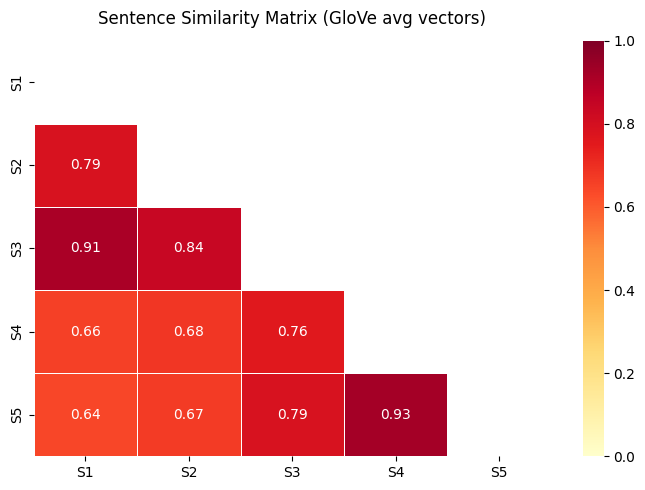


Sentence Legend:
  S1: Artificial intelligence is transforming business.
  S2: Machine learning models analyse large datasets.
  S3: Deep learning is widely used in image recognition.
  S4: Jewellery diamonds are valued for their clarity.
  S5: Gold and diamonds are popular luxury items.


In [87]:
## Short labels for readability
labels = [f"S{i+1}" for i in range(len(sentences))]

sim_df = pd.DataFrame(similarity_matrix, index=labels, columns=labels).round(3)
mask = np.triu(np.ones_like(sim_df, dtype=bool)) 

## Heatmap 
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    sim_df, 
    annot=True, 
    fmt=".2f", 
    cmap="YlOrRd",
    vmin=0, 
    vmax=1, 
    linewidths=0.5, 
    ax=ax, 
    mask=mask
)
ax.set_title("Sentence Similarity Matrix (GloVe avg vectors)", pad=12)
plt.tight_layout()
plt.show()

## Legend — which label maps to which sentence
print("\nSentence Legend:")
for label, sentence in zip(labels, sentences):
    print(f"  {label}: {sentence}")

### COMMENTARY ON SENTENCE SIMILARITY
- Sample sentences were vectorised using word embedding from Glove
- Cosine similarity between the sentences was computed 
- Sentences S1 - S3 are realted to AI/ML and together demostrate high similarity score 
- S4-S5 are related to Jewellery and similarly demonstrate high similarity score 
- Similarity for all sentences is over 0.6 indicating similarity
    - This is probably driven by lingustic structure and common words 

------------------------------------------------
Section 9: Transformer Application Example
------------------------------------------------

In [88]:
print("\nSentiment Analysis Example")
sentiment = pipeline("sentiment-analysis")
texts = [
    "This product is excellent and works perfectly.",
    "The service was slow and disappointing."
]

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.



Sentiment Analysis Example


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1359.74it/s, Materializing param=pre_classifier.weight]                                  


In [89]:
results = sentiment(texts)

In [90]:
for text, result in zip(texts, results):
    print("\nText:", text)
    print("Sentiment:", result)


Text: This product is excellent and works perfectly.
Sentiment: {'label': 'POSITIVE', 'score': 0.9998756647109985}

Text: The service was slow and disappointing.
Sentiment: {'label': 'NEGATIVE', 'score': 0.9996953010559082}
